# Model Training

> Training an MLP on a simple binary classification task

Imports

In [2]:
from learningdynamics.models import MLP, init_weights
from learningdynamics.datasets import YinYangDataset
from learningdynamics.visualization import plot_decision_boundary_movie
import matplotlib.pyplot as plt
import matplotlib
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from safetensors.torch import save_model
from torch.optim import SGD
from torchvision import datasets, transforms
import numpy as np
import torch

In [3]:
# | export
import os
import json

Notebook configuration

In [4]:
# Visualization
FIGSIZE = (5, 5)
matplotlib.rc("figure", figsize=FIGSIZE)

# MLP settings
HIDDEN_NEURONS = [256, 32, 32, 16, 16]  # only valid for HiddenLayerModel
NONLINEARITY = "relu"

# Model training settings
BATCH_SIZE = 4_096
NUM_EPOCHS = 60
LEARNING_RATE = 1e-1
PRINT_FREQ = 1

Define a YinYang dataset

In [5]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),  # first, convert image to PyTorch tensor
        transforms.Normalize((0.1307,), (0.3081,)),  # normalize inputs
    ]
)
dataset = datasets.MNIST(
    root="/mnt/datasets/", train=True, download=True, transform=transform
)

Visualize the dataset as a sanity check.

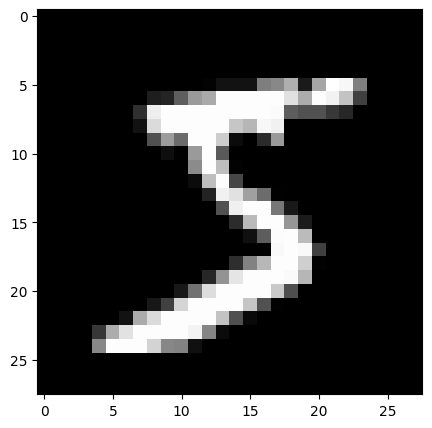

In [6]:
plt.imshow(dataset.data[0], cmap="gray")

Define a MLP model

In [7]:
model = MLP(
    config=HIDDEN_NEURONS,
    in_features=torch.flatten(dataset.data, start_dim=1).shape[-1],
    out_features=10,
    nonlinearity=NONLINEARITY,
)
model.apply(init_weights)

MLP(
  (features): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=10, bias=True)
  )
)

Setup model training

In [8]:
dataloader = DataLoader(dataset=dataset, shuffle=True, batch_size=BATCH_SIZE)
criterion = CrossEntropyLoss()  # Use CrossEntropyLoss for multi-class classification
optimizer = SGD(model.parameters(), lr=LEARNING_RATE * 0.6, weight_decay=1e-4)

Train the model.

In [9]:
device = "cuda:0"
model.to(device=device)
model.train()

loss_vector = []
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0  # Track loss within the epoch

    for batch_idx, (input, label) in enumerate(dataloader):
        input, label = input.to(device), label.to(device)
        label = label.squeeze()

        optimizer.zero_grad()
        output = model(input)

        loss = criterion(output, label.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()  # Accumulate loss

    epoch_loss = running_loss / len(dataloader)  # Average loss over all batches
    loss_vector.append(epoch_loss)  # Store loss for later analysis

    if (epoch + 1) % PRINT_FREQ == 0:
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")

Epoch 1/60, Loss: 2.2276
Epoch 2/60, Loss: 1.9804
Epoch 3/60, Loss: 1.7788
Epoch 4/60, Loss: 1.4706
Epoch 5/60, Loss: 1.1284
Epoch 6/60, Loss: 0.7687
Epoch 7/60, Loss: 0.6624
Epoch 8/60, Loss: 0.4713
Epoch 9/60, Loss: 0.4880
Epoch 10/60, Loss: 0.3993
Epoch 11/60, Loss: 0.3674
Epoch 12/60, Loss: 0.3475
Epoch 13/60, Loss: 0.3352
Epoch 14/60, Loss: 0.3141
Epoch 15/60, Loss: 0.3053
Epoch 16/60, Loss: 0.2792
Epoch 17/60, Loss: 0.2677
Epoch 18/60, Loss: 0.2655
Epoch 19/60, Loss: 0.2529
Epoch 20/60, Loss: 0.2383
Epoch 21/60, Loss: 0.2385
Epoch 22/60, Loss: 0.2233
Epoch 23/60, Loss: 0.2154
Epoch 24/60, Loss: 0.2101
Epoch 25/60, Loss: 0.2026
Epoch 26/60, Loss: 0.1991
Epoch 27/60, Loss: 0.1933
Epoch 28/60, Loss: 0.1859
Epoch 29/60, Loss: 0.1818
Epoch 30/60, Loss: 0.1742
Epoch 31/60, Loss: 0.1752
Epoch 32/60, Loss: 0.1675
Epoch 33/60, Loss: 0.1615
Epoch 34/60, Loss: 0.1571
Epoch 35/60, Loss: 0.1567
Epoch 36/60, Loss: 0.1515
Epoch 37/60, Loss: 0.1463
Epoch 38/60, Loss: 0.1467
Epoch 39/60, Loss: 0.

In [10]:
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        root="/mnt/datasets/", train=False, download=True, transform=transform
    )
)


def test_accuracy(model, test_loader):
    model.eval()
    model.cpu()
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    accuracy = correct / total
    print(f"Accuracy: {accuracy * 100:.2f}%")


test_accuracy(model, test_loader)

Accuracy: 95.98%


Save the model using `safetensors`

In [11]:
metadata_dict = {
    "config": str(HIDDEN_NEURONS),
    "dataset": str(dataset),
    "nonlinearity": NONLINEARITY,
}
save_model(model, "../saved_weights/mnist_model.safetensors", metadata=metadata_dict)

Parser for future use

In [12]:
# | export
def safetensors_metadata_parser(
    file_path: str,  # thing
):
    "Parse the metadata from safetensors file"
    header_size = 8
    meta_data = {}
    if os.stat(file_path).st_size > header_size:
        with open(file_path, "rb") as f:
            b8 = f.read(header_size)
            if len(b8) == header_size:
                header_len = int.from_bytes(b8, "little", signed=False)
                headers = f.read(header_len)
                if len(headers) == header_len:
                    meta_data = sorted(
                        json.loads(headers.decode("utf-8"))
                        .get("__metadata__", meta_data)
                        .items()
                    )
    meta_data_dict = {}
    for k, v in meta_data:
        meta_data_dict[k] = v
    return meta_data_dict